In [4]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

url = "https://raw.githubusercontent.com/ageron/handson-ml/master/datasets/housing/housing.csv"
df = pd.read_csv(url)

df.head()
#df.columns


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [5]:
#pip install pandas==1.5.3


In [6]:
import numpy, scipy, sklearn

print(numpy.__version__)
print(scipy.__version__)
print(sklearn.__version__)

1.23.5
1.10.1
1.2.2


In [7]:
df = df.rename(columns={"median_house_value": "Price"})


In [8]:
df.shape

(20640, 10)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   Price               20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [10]:

df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,Price
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [11]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
Price                   0
ocean_proximity         0
dtype: int64

In [12]:
df["total_bedrooms"] = df["total_bedrooms"].fillna(df["total_bedrooms"].mean())


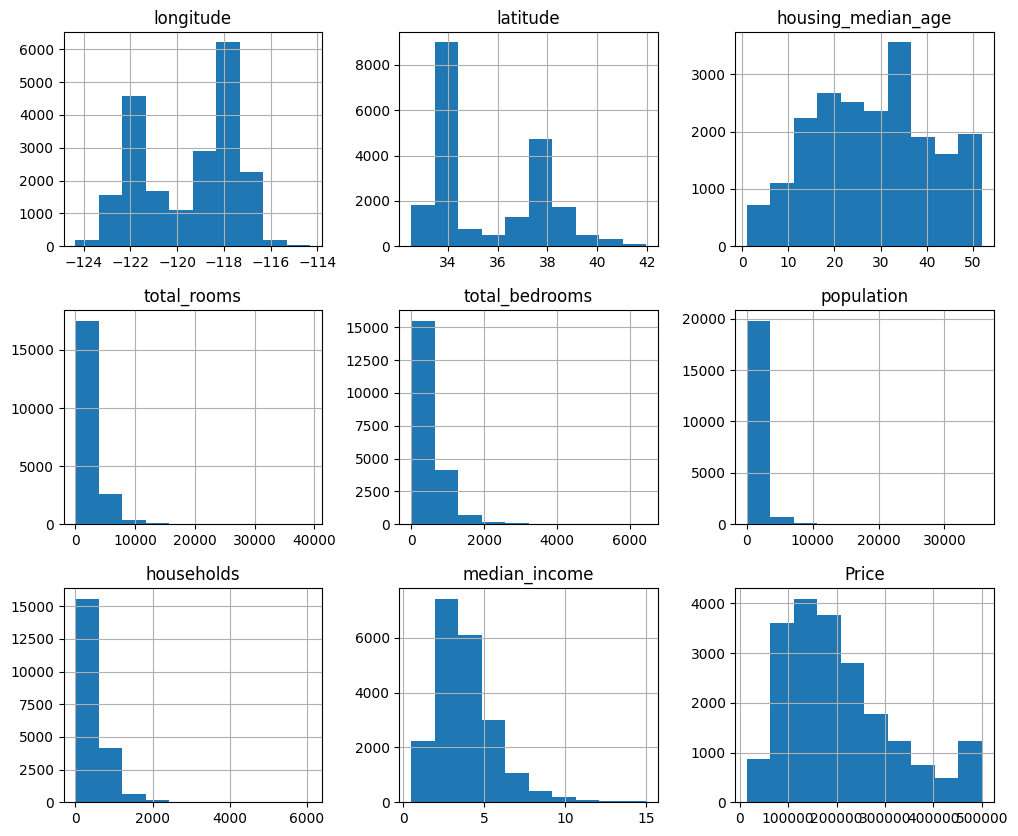

In [13]:
import matplotlib.pyplot as plt

df.hist(figsize=(12,10))
plt.show()

In [14]:
df["Price"].describe()

count     20640.000000
mean     206855.816909
std      115395.615874
min       14999.000000
25%      119600.000000
50%      179700.000000
75%      264725.000000
max      500001.000000
Name: Price, dtype: float64

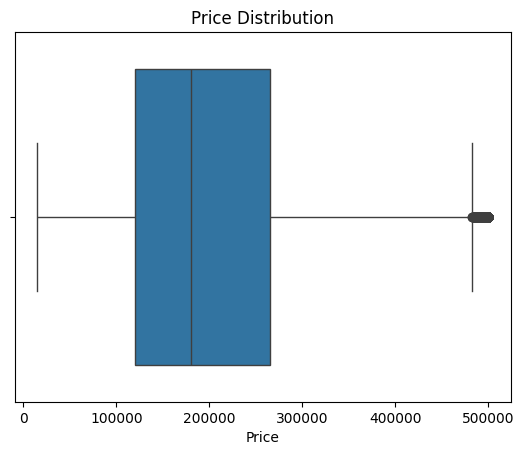

In [15]:
import seaborn as sns

sns.boxplot(x=df["Price"])
plt.title("Price Distribution")
plt.show()

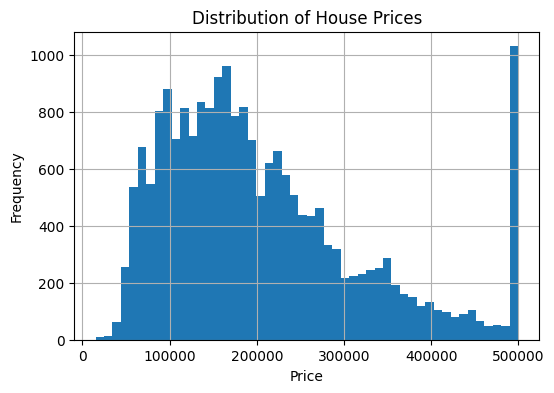

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
df["Price"].hist(bins=50)
plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

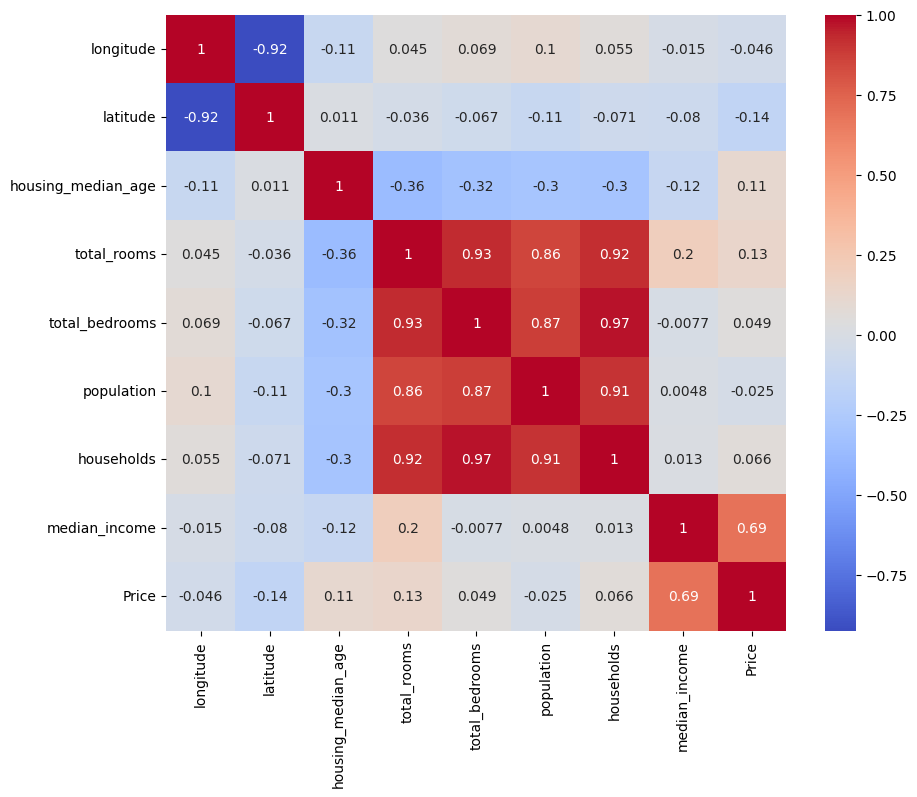

In [17]:
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

In [18]:
numeric_df = df.select_dtypes(include=["number"])
numeric_df.corr()["Price"].sort_values(ascending=False)

Price                 1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049454
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: Price, dtype: float64

In [16]:
X = df.drop("Price", axis=1)
X = X.select_dtypes(include=["number"])   #  numeric colums
y = df["Price"]


In [17]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# DataFrame
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# >>> BURAYA EKLİYORSUN <<<
import joblib
joblib.dump(scaler, "scaler.joblib")


['scaler.joblib']

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42
)


In [19]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)


In [20]:
rf_model.fit(X_train, y_train)


RandomForestRegressor(n_estimators=200, random_state=42)

In [21]:
y_pred = rf_model.predict(X_test)


In [22]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# 1️⃣ Train Random Forest model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

rf_model.fit(X_train, y_train)

# 2️⃣ Predictions
y_train_pred = rf_model.predict(X_train)
y_test_pred = rf_model.predict(X_test)

# 3️⃣ Train Metrics
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
mae_train = mean_absolute_error(y_train, y_train_pred)
r2_train = r2_score(y_train, y_train_pred)

# 4️⃣ Test Metrics
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
mae_test = mean_absolute_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)

# 5️⃣ Print Results
print("===== TRAIN METRICS =====")
print("RMSE:", rmse_train)
print("MAE:", mae_train)
print("R2 Score:", r2_train)

print("\n===== TEST METRICS =====")
print("RMSE:", rmse_test)
print("MAE:", mae_test)
print("R2 Score:", r2_test)

===== TRAIN METRICS =====
RMSE: 18419.919152868257
MAE: 11900.99344537306
R2 Score: 0.9746185703353123

===== TEST METRICS =====
RMSE: 49932.85834055296
MAE: 32168.271969476744
R2 Score: 0.809731894129363


In [23]:
rf_model.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'criterion': 'squared_error',
 'max_depth': None,
 'max_features': 1.0,
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': 42,
 'verbose': 0,
 'warm_start': False}

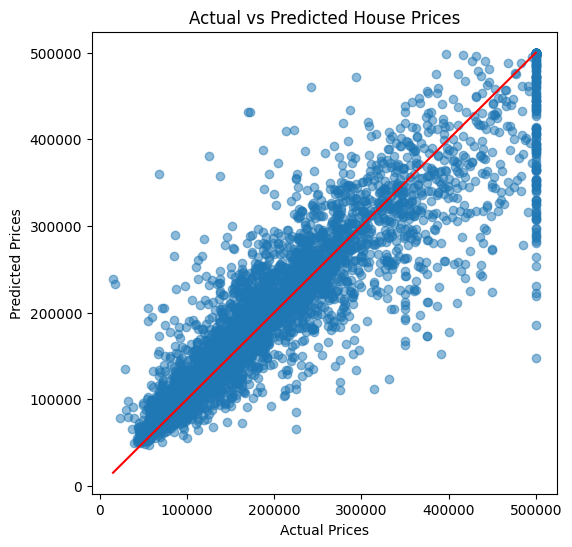

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.scatter(y_test, y_test_pred, alpha=0.5)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red")

plt.show()

In [25]:
import joblib

joblib.dump(rf_model, "../models/regression/random_forest_model.pkl")

['../models/regression/random_forest_model.pkl']

In [26]:
model_loaded = joblib.load("../models/regression/random_forest_model.pkl")

In [27]:
!python ../src/regression_model/inference_regression.py

Traceback (most recent call last):
  File "C:\Users\nimte\OneDrive\Desktop\real-estate-financial-assistant\src\regression_model\inference_regression.py", line 5, in <module>
    model = joblib.load("../models/regression/random_forest_model.pkl")
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\nimte\AppData\Local\Programs\Python\Python311\Lib\site-packages\joblib\numpy_pickle.py", line 749, in load
    obj = _unpickle(
          ^^^^^^^^^^
  File "C:\Users\nimte\AppData\Local\Programs\Python\Python311\Lib\site-packages\joblib\numpy_pickle.py", line 626, in _unpickle
    obj = unpickler.load()
          ^^^^^^^^^^^^^^^^
  File "C:\Users\nimte\AppData\Local\Programs\Python\Python311\Lib\pickle.py", line 1213, in load
    dispatch[key[0]](self)
  File "C:\Users\nimte\AppData\Local\Programs\Python\Python311\Lib\pickle.py", line 1538, in load_stack_global
    self.append(self.find_class(module, name))
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  Fi

Cpmpleted;
Load dataset ✔

EDA ✔

Scaling ✔

Train/Test split ✔

Random Forest training ✔

Evaluation (RMSE, MAE, R²) ✔

Save model ✔

Inference script ✔

✅ Regression Task finished